# Drug Side Effects Analysis

Exploratory analysis of the drugs side-effects dataset (2,931 drugs).
Goals: clean and prepare the data, encode categorical fields for correlation analysis,
and identify patterns in medical conditions, drug classes, and specific side effects
(hives, difficult breathing, itching, etc.).

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [76]:
from google.colab import files
uploaded = files.upload()


Saving drugs_side_effects_drugs_com.csv to drugs_side_effects_drugs_com (1).csv


## Uploading and reading the raw CSV data.

In [77]:
data = pd.read_csv('drugs_side_effects_drugs_com.csv')

In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2702 non-null   object 
 9   csa                            2931 non-null   object 
 10  alcohol                        1377 non-null   object 
 11  related_drugs                  1462 non-null   object 
 12  medical_condition_description  2897 non-null   o

In [79]:
data.head()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,N,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,N,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html


In [80]:
data.tail()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",2%,Rx,X,3,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0,https://www.drugs.com/mtm/benzphetamine.html,https://www.drugs.com/condition/obesity.html
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,1%,Rx,C,4,X,NaN,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN,https://www.drugs.com/mtm/fenfluramine.html,https://www.drugs.com/condition/obesity.html
2928,Fendique ER,Weight Loss,NaN,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0%,Rx,C,3,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN,https://www.drugs.com/pro/fendique-er.html,https://www.drugs.com/condition/obesity.html
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0%,Rx,NaN,N,NaN,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN,https://www.drugs.com/imcivree.html,https://www.drugs.com/condition/obesity.html
2930,setmelanotide,Weight Loss,hives ; difficult breathing; swelling of your ...,setmelanotide,Melanocortin receptor agonists,Imcivree,0%,Rx,NaN,N,NaN,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN,https://www.drugs.com/mtm/setmelanotide.html,https://www.drugs.com/condition/obesity.html


In [81]:
data.shape

(2931, 17)

In [82]:
data.columns

Index(['drug_name', 'medical_condition', 'side_effects', 'generic_name',
       'drug_classes', 'brand_names', 'activity', 'rx_otc',
       'pregnancy_category', 'csa', 'alcohol', 'related_drugs',
       'medical_condition_description', 'rating', 'no_of_reviews', 'drug_link',
       'medical_condition_url'],
      dtype='object')

In [83]:
data.isna().sum()

,0
drug_name,0
medical_condition,0
side_effects,124
generic_name,43
drug_classes,82
brand_names,1213
activity,0
rx_otc,1
pregnancy_category,229
csa,0


In [84]:
print (f"Amount of duplicates:{data.duplicated().sum()}")

Amount of duplicates:0


In [85]:
data['rating'] = pd.to_numeric(data['rating'], errors = 'coerce')
data['no_of_reviews'] = pd.to_numeric(data['no_of_reviews'], errors = 'coerce')

In [86]:
data.dtypes.value_counts()

,count
object,15
float64,2


In [87]:
data['activity'] = data['activity'].astype(str).str.replace(r'\s+', '', regex = True).str.rstrip('%').astype('float')/100

In [88]:
data['activity'].head()

,activity
0,0.87
1,0.82
2,0.48
3,0.41
4,0.39


In [89]:
print("total missing values in the dataset {}".format(data.isnull().sum().sum()))
print('Number of instances = %d' % (data.shape[0]))
print('Number of instances = %d' % (data.shape[1]))
print('Number of instances = ')
for col in data.columns:
    print('\t%s: %d' % (col,data[col].isna().sum()))

total missing values in the dataset 7439
Number of instances = 2931
Number of instances = 17
Number of instances = 
	drug_name: 0
	medical_condition: 0
	side_effects: 124
	generic_name: 43
	drug_classes: 82
	brand_names: 1213
	activity: 0
	rx_otc: 1
	pregnancy_category: 229
	csa: 0
	alcohol: 1554
	related_drugs: 1469
	medical_condition_description: 34
	rating: 1345
	no_of_reviews: 1345
	drug_link: 0
	medical_condition_url: 0


## Handling Missing Values
Each column is treated differently based on what the missing value likely means:
- `alcohol`: missing → assumed no interaction (`0`), `'X'` → interaction present (`1`)
- `side_effects`, `related_drugs`, `generic_name`, `drug_classes`: missing → labeled `'Unknown'`
- `rating`, `no_of_reviews`: missing → `0` (no reviews yet)
- `rx_otc`, `pregnancy_category`: missing → labeled `'Unknown'`

`brand_names` is left with nulls, since it isn't used in later analysis.

In [90]:
data['alcohol'] = data['alcohol'].replace(np.nan,'0')
data['alcohol'] = data['alcohol'].replace('X','1')

In [91]:
data['side_effects'] = data['side_effects'].fillna('Unknown')
data['related_drugs'] = data['related_drugs'].fillna('Unknown')

In [92]:
data['rating'] = data['rating'].fillna('0')
data['no_of_reviews'] = data['no_of_reviews'].fillna('0')
data['generic_name'] = data['generic_name'].replace(np.nan,'Unknown')
data['drug_classes'] = data['drug_classes'].replace(np.nan,'Unknown')


In [93]:
data['rx_otc'].unique()


array(['Rx', 'Rx/OTC', 'OTC', nan], dtype=object)

In [94]:
data['pregnancy_category'].unique()

array(['D', 'C', 'X', 'B', 'N', nan, 'A'], dtype=object)

In [95]:
data['rx_otc'] = data['rx_otc'].replace(np.nan, 'Unknown')
data['pregnancy_category'] = data['pregnancy_category'].replace(np.nan, 'Unknown')

In [96]:
data.head()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",0.87,Rx,D,N,1,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",0.82,Rx,C,N,1,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",0.48,Rx,D,N,0,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,0.41,Rx,X,N,1,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",0.39,Rx,B,N,0,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html


In [97]:
dfs = data.copy()
dfs

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",0.87,Rx,D,N,1,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",0.82,Rx,C,N,1,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",0.48,Rx,D,N,0,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,0.41,Rx,X,N,1,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",0.39,Rx,B,N,0,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",0.02,Rx,X,3,1,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0,https://www.drugs.com/mtm/benzphetamine.html,https://www.drugs.com/condition/obesity.html
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,0.01,Rx,C,4,1,Unknown,Weight Loss (Obesity/Overweight) More than hal...,0,0,https://www.drugs.com/mtm/fenfluramine.html,https://www.drugs.com/condition/obesity.html
2928,Fendique ER,Weight Loss,Unknown,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0.00,Rx,C,3,1,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,0,0,https://www.drugs.com/pro/fendique-er.html,https://www.drugs.com/condition/obesity.html
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0.00,Rx,Unknown,N,0,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,0,0,https://www.drugs.com/imcivree.html,https://www.drugs.com/condition/obesity.html


## Verify missing values dropped after the cleaning above.

In [98]:
print("total missing values in the dataset {}".format(data.isnull().sum().sum()))
print('Number of instances = %d' % (data.shape[0]))
print('Number of instances = %d' % (data.shape[1]))
print('Number of instances = ')
for col in data.columns:
    print('\t%s: %d' % (col,data[col].isna().sum()))

total missing values in the dataset 1247
Number of instances = 2931
Number of instances = 17
Number of instances = 
	drug_name: 0
	medical_condition: 0
	side_effects: 0
	generic_name: 0
	drug_classes: 0
	brand_names: 1213
	activity: 0
	rx_otc: 0
	pregnancy_category: 0
	csa: 0
	alcohol: 0
	related_drugs: 0
	medical_condition_description: 34
	rating: 0
	no_of_reviews: 0
	drug_link: 0
	medical_condition_url: 0


In [99]:
data_version2 = data.copy()

In [100]:
data_version2

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",0.87,Rx,D,N,1,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",0.82,Rx,C,N,1,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",0.48,Rx,D,N,0,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,0.41,Rx,X,N,1,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",0.39,Rx,B,N,0,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",0.02,Rx,X,3,1,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0,https://www.drugs.com/mtm/benzphetamine.html,https://www.drugs.com/condition/obesity.html
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,0.01,Rx,C,4,1,Unknown,Weight Loss (Obesity/Overweight) More than hal...,0,0,https://www.drugs.com/mtm/fenfluramine.html,https://www.drugs.com/condition/obesity.html
2928,Fendique ER,Weight Loss,Unknown,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0.00,Rx,C,3,1,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,0,0,https://www.drugs.com/pro/fendique-er.html,https://www.drugs.com/condition/obesity.html
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0.00,Rx,Unknown,N,0,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,0,0,https://www.drugs.com/imcivree.html,https://www.drugs.com/condition/obesity.html


In [101]:
data_version2.to_csv('drugs_side_effects_drugs_com_version2.csv', index = False)

## Label Encoding
Convert categorical columns (`csa`, `rx_otc`, `generic_name`, `medical_condition`,
`pregnancy_category`, `side_effects`) into numeric labels so they can be used in
correlation analysis and scaling.

In [102]:
data_version3 = pd.read_csv('drugs_side_effects_drugs_com_version2.csv')

In [103]:
data_version3['pregnancy_category'].unique()

array(['D', 'C', 'X', 'B', 'N', 'Unknown', 'A'], dtype=object)

In [104]:
data_version3['rx_otc'].unique()

array(['Rx', 'Rx/OTC', 'OTC', 'Unknown'], dtype=object)

In [105]:
data_version3['medical_condition'].unique()

array(['Acne', 'ADHD', 'AIDS/HIV', 'Allergies', "Alzheimer's", 'Angina',
       'Anxiety', 'Asthma', 'Bipolar Disorder', 'Bronchitis', 'Cancer',
       'Cholesterol', 'Colds & Flu', 'Constipation', 'COPD', 'Covid 19',
       'Depression', 'Diabetes (Type 1)', 'Diabetes (Type 2)', 'Diarrhea',
       'Eczema', 'Erectile Dysfunction', 'Gastrointestinal',
       'GERD (Heartburn)', 'Gout', 'Hair Loss', 'Hayfever', 'Herpes',
       'Hypertension', 'Hypothyroidism', 'IBD (Bowel)', 'Incontinence',
       'Insomnia', 'Menopause', 'Migraine', 'Osteoarthritis',
       'Osteoporosis', 'Pain', 'Pneumonia', 'Psoriasis',
       'Rheumatoid Arthritis', 'Schizophrenia', 'Seizures', 'Stroke',
       'Swine Flu', 'UTI', 'Weight Loss'], dtype=object)

In [106]:
data_version3['generic_name'].unique()

array(['doxycycline', 'spironolactone', 'minocycline', ...,
       'fenfluramine', 'phendimetrazine tartrate', 'setmelanotide'],
      dtype=object)

In [107]:
data_version3['csa'].unique()

array(['N', '2', '4', 'U', 'M', '5', '3'], dtype=object)

In [108]:
label_encoder = LabelEncoder()

In [109]:
data_version3["csa"] = label_encoder.fit_transform(data_version3["csa"])
data_version3["rx_otc"] = label_encoder.fit_transform(data_version3["rx_otc"])
data_version3["generic_name"] = label_encoder.fit_transform(data_version3["generic_name"])
data_version3["medical_condition"] = label_encoder.fit_transform(data_version3["medical_condition"])
data_version3["pregnancy_category"] = label_encoder.fit_transform(data_version3["pregnancy_category"])
data_version3["side_effects"] = label_encoder.fit_transform(data_version3["side_effects"])

In [110]:
data_version3['generic_name'].unique()

array([ 642, 1270, 1034, ...,  729, 1157, 1259])

In [111]:
data_version3['csa'].unique()

array([5, 0, 2, 6, 4, 3, 1])

In [112]:
data_version3['medical_condition'].unique()

array([ 2,  0,  1,  3,  4,  5,  6,  7,  8,  9, 11, 12, 13, 14, 10, 15, 16,
       17, 18, 19, 20, 21, 23, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46])

In [113]:
data_version3['rx_otc'].unique()

array([1, 2, 0, 3])

In [114]:
data_version3['side_effects'].unique()

array([  15, 1972, 2697, ..., 1647,  416, 1706])

In [115]:
df = pd.DataFrame(data_version3,columns = ('generic_name','medical_condition','csa','rx_otc','side_effects','rating','no_of_reviews','pregnancy_category','alcohol'))

In [116]:
df.head()

,generic_name,medical_condition,csa,rx_otc,side_effects,rating,no_of_reviews,pregnancy_category,alcohol
0,642,2,5,1,15,6.8,760.0,3,1
1,1270,2,5,1,1972,7.2,449.0,2,1
2,1034,2,5,1,2697,5.7,482.0,3,0
3,903,2,5,1,2570,7.9,623.0,6,1
4,505,2,5,1,1260,7.4,146.0,1,0


## Feature Scaling
Standardize the encoded features (mean 0, standard deviation 1) so no single
column dominates the correlation/heatmap purely due to scale.

In [117]:
scaler = StandardScaler()
scaler.fit(df)
scaled_data = scaler.transform(df)
scaled_data

array([[-0.11111578, -1.43400434,  0.27417787, ...,  5.10119829,
         0.28892455,  1.06232778],
       [ 1.50040103, -1.43400434,  0.27417787, ...,  2.89586941,
        -0.43301735,  1.06232778],
       [ 0.89479917, -1.43400434,  0.27417787, ...,  3.12987537,
         0.28892455, -0.94132905],
       ...,
       [ 1.21043065,  1.82918864, -3.42485705, ..., -0.28802985,
        -0.43301735,  1.06232778],
       [ 1.47217383,  1.82918864,  0.27417787, ..., -0.28802985,
         1.73280834, -0.94132905],
       [ 1.47217383,  1.82918864,  0.27417787, ..., -0.28802985,
         1.73280834, -0.94132905]])

In [118]:
df_std = pd.DataFrame(scaler.fit_transform(df), columns = df.columns)
df_std

,generic_name,medical_condition,csa,rx_otc,side_effects,rating,no_of_reviews,pregnancy_category,alcohol
0,-0.111116,-1.434004,0.274178,-0.170257,-1.678954,0.819930,5.101198,0.288925,1.062328
1,1.500401,-1.434004,0.274178,-0.170257,0.778579,0.925271,2.895869,-0.433017,1.062328
2,0.894799,-1.434004,0.274178,-0.170257,1.689009,0.530244,3.129875,0.288925,-0.941329
3,0.558639,-1.434004,0.274178,-0.170257,1.529527,1.109617,4.129719,2.454750,1.062328
4,-0.462673,-1.434004,0.274178,-0.170257,-0.115526,0.977941,0.747269,-1.154959,-0.941329
...,...,...,...,...,...,...,...,...,...
2926,-0.832193,1.829189,-3.424857,-0.170257,0.757231,1.004277,-0.167481,2.454750,1.062328
2927,0.112136,1.829189,-2.500098,-0.170257,0.370455,-0.970861,-0.288030,-0.433017,1.062328
2928,1.210431,1.829189,-3.424857,-0.170257,-1.029724,-0.970861,-0.288030,-0.433017,1.062328
2929,1.472174,1.829189,0.274178,-0.170257,-1.175392,-0.970861,-0.288030,1.732808,-0.941329


## Correlation Heatmap
Correlation between encoded/scaled features. Note: since most of these are
label-encoded categories rather than truly continuous variables, correlation
values here indicate association patterns in the encoding, not strict linear
relationships.

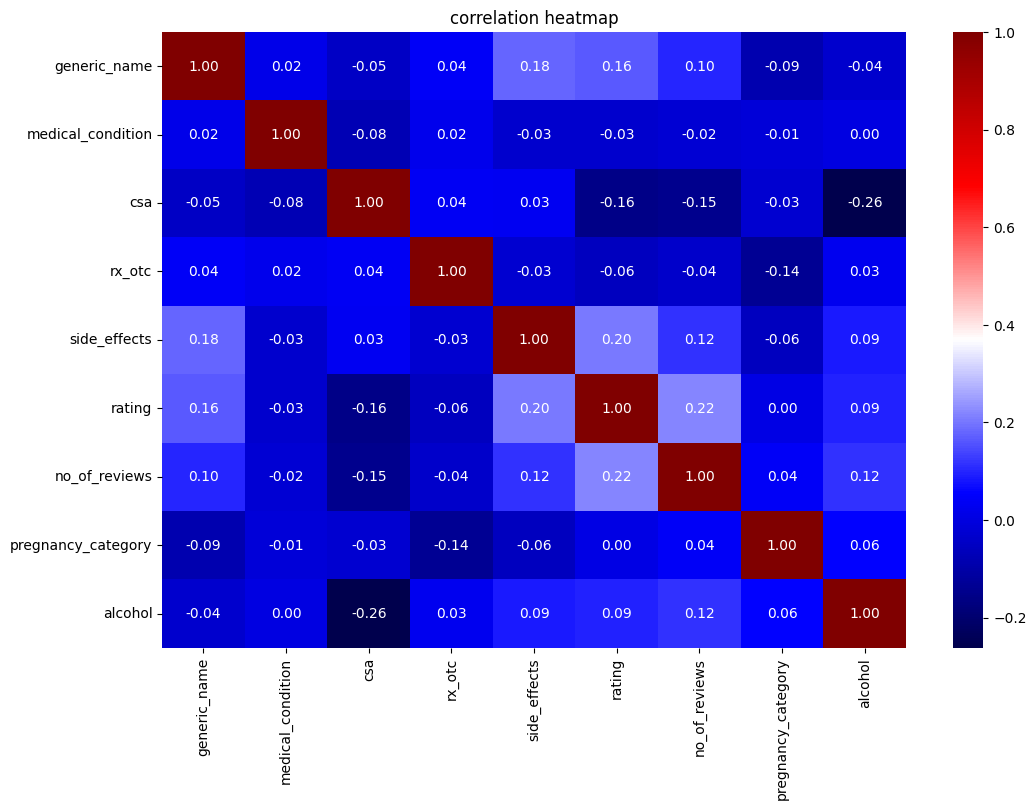

In [119]:
plt.figure(figsize = (12,8))
sns.heatmap(df.corr(), annot = True, cmap = 'seismic', fmt = '.2f')
plt.title('correlation heatmap')
plt.show()

## Frequency Analysis
Reload the cleaned data fresh (`data_version4`) and look at how often each
medical condition, side effect, and drug class occurs.

In [120]:
data_version4 = pd.read_csv('drugs_side_effects_drugs_com_version2.csv')

In [121]:
medical_condition_counts = data_version4['medical_condition'].value_counts().sort_values(ascending = False)
print("\nMedical condition occurence and frequency (sorted from highest to lowest):")
print(medical_condition_counts)


Medical condition occurence and frequency (sorted from highest to lowest):
medical_condition
Pain                    264
Colds & Flu             245
Acne                    238
Hypertension            177
Osteoarthritis          129
Hayfever                124
Eczema                  122
AIDS/HIV                109
Diabetes (Type 2)       104
Psoriasis                93
GERD (Heartburn)         77
Pneumonia                72
Bronchitis               71
Angina                   71
Migraine                 61
Insomnia                 60
Constipation             60
Diabetes (Type 1)        57
Osteoporosis             56
ADHD                     55
Depression               51
Seizures                 50
Bipolar Disorder         47
UTI                      46
Asthma                   45
Cholesterol              45
Anxiety                  45
Diarrhea                 38
Covid 19                 34
Rheumatoid Arthritis     33
Alzheimer's              27
COPD                     23
Weight Los

In [122]:
medical_condition_counts.to_csv('medical_condition_counts.csv')

### Side Effects Breakdown
`side_effects` contains multiple effects per drug separated by semicolons —
split and count each one individually.

In [123]:
from collections import Counter
import re

In [124]:
def extract_side_effects(text):
    return [effect.strip() for effect in re.split(r'[;]', text)]

In [125]:
side_effects = data_version4['side_effects'].dropna().apply(extract_side_effects).explode()
side_effect_counts = side_effects.value_counts().sort_values(ascending = True)
print("\nSide effects occurence and frequency (sorted from highest to lowest):")
print(side_effect_counts)


Side effects occurence and frequency (sorted from highest to lowest):
side_effects
problems with balance, walking, or muscle movement                                                                                                                                          1
drooling                                                                                                                                                                                    1
skin darkening                                                                                                                                                                              1
increased heart rate                                                                                                                                                                        1
or low sodium level - headache , confusion, slurred speech, severe weakness, vomiting, loss of coordination, feeling unsteady. Common Exforge HCT side effec

In [126]:
print(side_effect_counts)

side_effects
problems with balance, walking, or muscle movement                                                                                                                                          1
drooling                                                                                                                                                                                    1
skin darkening                                                                                                                                                                              1
increased heart rate                                                                                                                                                                        1
or low sodium level - headache , confusion, slurred speech, severe weakness, vomiting, loss of coordination, feeling unsteady. Common Exforge HCT side effects may include: dizziness       1
                                     

In [127]:
side_effect_counts.to_csv('side_effect_counts.csv')

### Drug Classes Breakdown
`drug_classes` can list multiple classes per drug separated by commas —
split and count each one individually.

In [128]:
def extract_drug_classes(text):
    return [effect.strip() for effect in re.split(r'[,]', text)]

In [129]:
drug_classes = data_version4['drug_classes'].dropna().apply(extract_drug_classes).explode()
drug_classes_counts = drug_classes.value_counts().sort_values(ascending=False)
print("\nDrug Classes occurence and frequency (sorted from highest to lowest):")
print(drug_classes_counts)


Drug Classes occurence and frequency (sorted from highest to lowest):
drug_classes
Upper respiratory combinations    245
Topical acne agents               125
Topical steroids                   94
Antihistamines                     82
Unknown                            82
                                 ... 
Antipseudomonal penicillins         1
CD52 monoclonal antibodies          1
Progestins                          1
Interferons                         1
Thioxanthenes                       1
Name: count, Length: 244, dtype: int64


In [130]:
drug_classes_counts.to_csv('drug_classes_counts.csv')

## Flagging Specific Conditions and Side Effects
Create boolean columns to isolate specific side effects (`Hives`, `Difficult Breathing`,
`Itching`) and specific categories (`Upper respiratory combinations`, `Topical steroids`,
`Pain`, `Colds & Flu`, `Acne`) for closer inspection and plotting below.

In [131]:
def has_hives(text):
    return 'hives' in text.lower()

In [132]:
data_version4['Hives'] = data_version4['side_effects'].apply(has_hives)

In [133]:
def has_difficult_breathing(text):
    return 'difficult breathing' in text.lower() or 'difficult breathing' in text.lower()

In [134]:
data_version4['Difficult Breathing'] = data_version4['side_effects'].apply(has_difficult_breathing)

In [135]:
def is_usc(text):
    return 'upper respiratory combinations' in text.lower()

data_version4['Upper respitory combinations'] = data_version4['drug_classes'].apply(is_usc)


def is_steriods(text):
    return 'topical steroids' in text.lower()

data_version4['Topical_steriods'] = data_version4['drug_classes'].apply(is_steriods)

In [136]:
def has_itching(text):
    return 'itching' in text.lower()
data_version4['Itching'] = data_version4['side_effects'].apply(has_itching)

def has_pain(text):
    return 'pain' in text.lower()
data_version4['Pain'] = data_version4['medical_condition'].apply(has_pain)

def has_colds_and_flu(text):
    return 'colds & flu' in text.lower()
data_version4['Colds & Flu'] = data_version4['medical_condition'].apply(has_colds_and_flu)

def has_acne(text):
    return 'acne' in text.lower()
data_version4['Acne'] = data_version4['medical_condition'].apply(has_acne)

## Visualizations
Bar charts showing the counts for each flagged condition/side effect/drug class above.

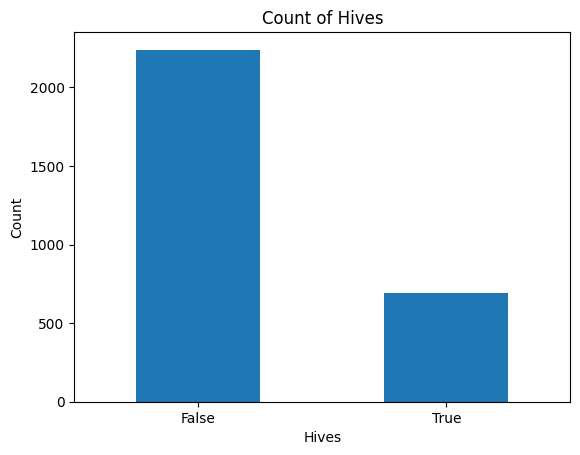

In [137]:
data_version4['Hives'].value_counts().plot(kind = 'bar')
plt.title('Count of Hives')
plt.xlabel('Hives')
plt.ylabel('Count')
plt.xticks([0,1], ['False', 'True'], rotation = 0)
plt.show()

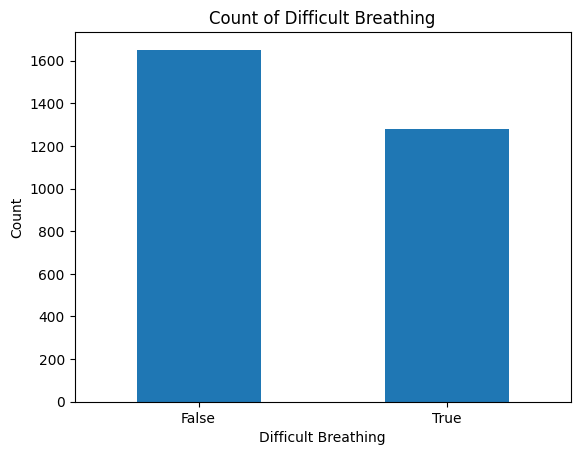

In [138]:
data_version4['Difficult Breathing'].value_counts().plot(kind = 'bar')
plt.title('Count of Difficult Breathing')
plt.xlabel('Difficult Breathing')
plt.ylabel('Count')
plt.xticks([0,1], ['False', 'True'], rotation = 0)
plt.show()

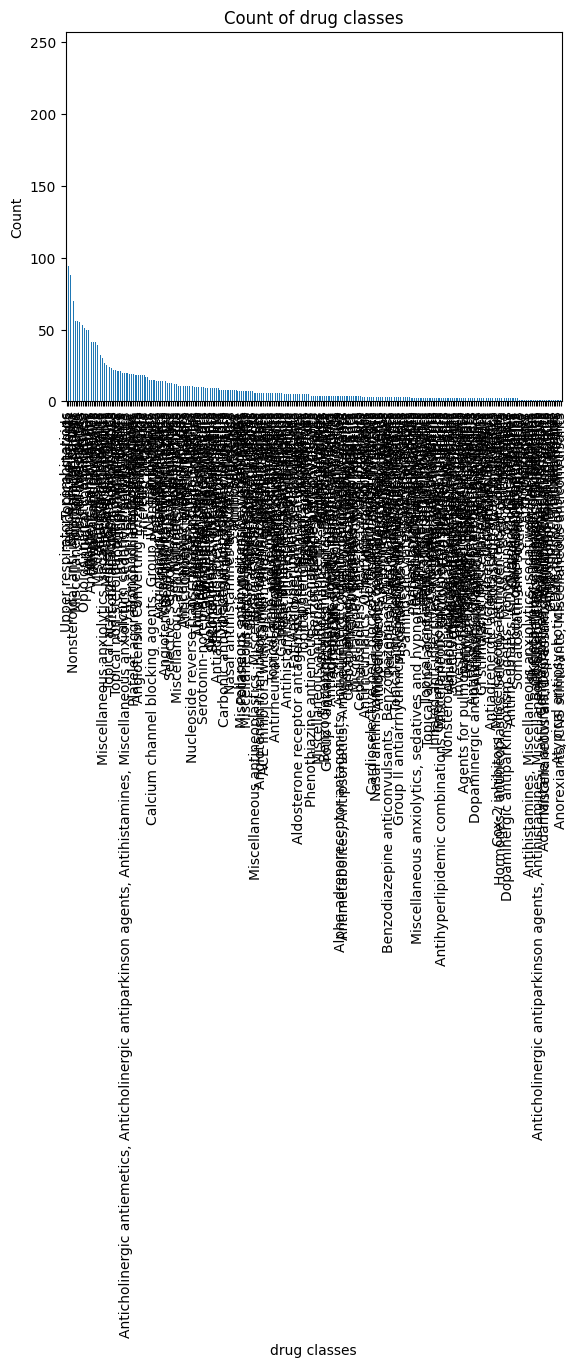

In [139]:
data_version4['drug_classes'].value_counts().plot(kind = 'bar')
plt.title('Count of drug classes')
plt.xlabel('drug classes')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

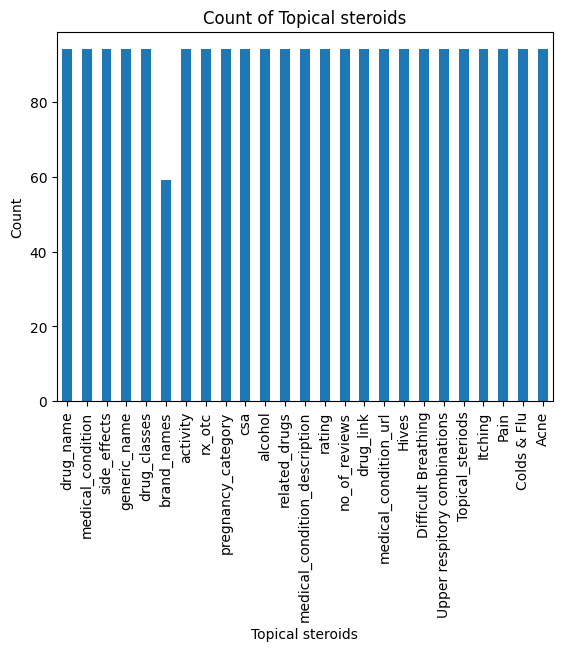

In [140]:
Tropical_steroids_counts = data_version4[data_version4['drug_classes'] == 'Topical steroids'].count()
Tropical_steroids_counts.plot(kind='bar')
plt.title('Count of Topical steroids')
plt.xlabel('Topical steroids')
plt.ylabel('Count')
plt.show()

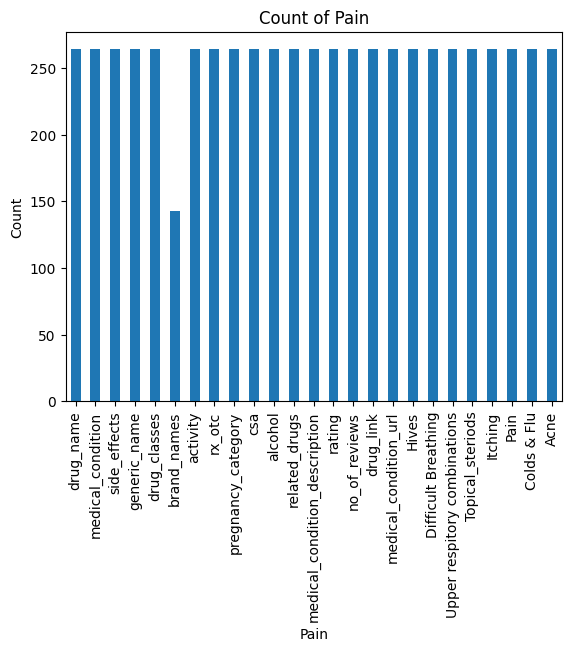

In [141]:
Pain_counts = data_version4[data_version4['medical_condition'] == 'Pain'].count()
Pain_counts.plot(kind='bar')
plt.title('Count of Pain')
plt.xlabel('Pain')
plt.ylabel('Count')
plt.show()

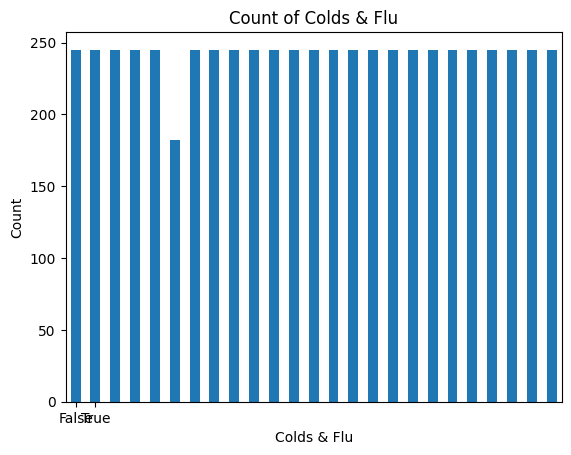

In [142]:
Colds_and_Flu_counts = data_version4[data_version4['medical_condition'] == 'Colds & Flu'].count()
Colds_and_Flu_counts.plot(kind = 'bar')
plt.title('Count of Colds & Flu')
plt.xlabel('Colds & Flu')
plt.ylabel('Count')
plt.xticks([0,1], ['False', 'True'], rotation = 0)
plt.show()

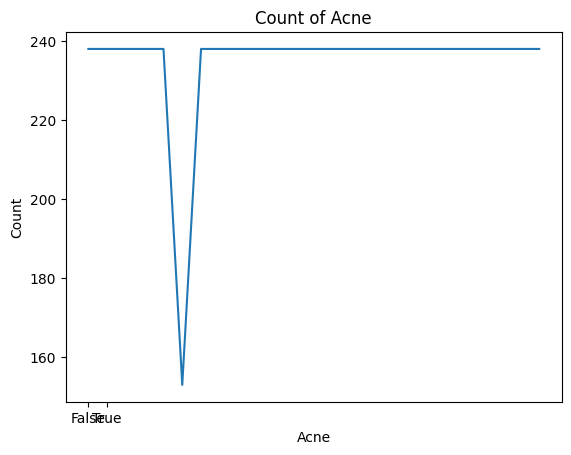

In [143]:
Acne_counts = data_version4[data_version4['medical_condition'] == 'Acne'].count()
Acne_counts.plot(kind = 'line')
plt.title('Count of Acne')
plt.xlabel('Acne')
plt.ylabel('Count')
plt.xticks([0,1], ['False', 'True'], rotation = 0)
plt.show()

In [144]:
print(side_effect_counts.sort_values(ascending=False).head(10))

side_effects
hives                                                             1788
difficult breathing                                               1130
difficulty breathing                                               450
itching                                                            275
a light-headed feeling, like you might pass out                    272
trouble breathing, swallowing, or talking                          266
wheezing                                                           266
unusual hoarseness                                                 266
tightness in the chest or throat                                   266
red, swollen, blistered, or peeling skin with or without fever     266
Name: count, dtype: int64


**Summary: Most common side effects (individual entries, from splitting the `side_effects`
field on semicolons):**
- Hives (1,788 mentions)
- Difficult breathing (1,130 mentions)
- Difficulty breathing (450 mentions)
- Itching (275 mentions)
- A light-headed feeling, like you might pass out (272 mentions)
- Trouble breathing, swallowing, or talking (266 mentions)
- Wheezing (266 mentions)
- Unusual hoarseness (266 mentions)
- Tightness in the chest or throat (266 mentions)
- Red, swollen, blistered, or peeling skin with or without fever (266 mentions)

Interestingly, allergic-reaction symptoms (hives, difficult/difficulty breathing,
swelling, wheezing) dominate the top of this list. That's a reflection of how
drug warning labels are written, not necessarily how common these reactions are
in practice — most listed drugs carry a standard allergic-reaction warning
("stop use and seek help if you experience hives, difficulty breathing..."),
so this phrase gets repeated across a large share of the 2,931 entries. This is
worth flagging as a data quality nuance: high frequency in this dataset reflects
frequency of *warning-label boilerplate*, not frequency of the side effect
actually occurring in patients.